# Ecommerce Conversion Funnel Analysis and Optimization

## Executive Summary

This project analyzes over 67 million user interaction events to understand conversion behavior across an e-commerce funnel and identify opportunities to improve sales performance.

The analysis reveals that the primary bottleneck occurs at the **view → cart stage**, with approximately **87% of users dropping off** before demonstrating purchase intent. In contrast, users who reach the cart stage show strong intent, with nearly **half completing a purchase**.

User behavior indicates that conversions often occur across multiple sessions rather than within a single visit. Additionally, pricing plays a critical role, with **mid-priced products (100–200)** achieving the highest conversion rates, while both low- and high-priced products underperform.

Overall, improving early-stage engagement, strengthening brand trust, and optimizing pricing strategies represent the most impactful opportunities to increase conversion rates and drive revenue growth.



### Background
Understanding how users move through an e-commerce platform is critical for improving conversion rates and maximizing revenue. While large volumes of user activity are generated, not all interactions lead to purchases. Identifying where users drop off in the conversion journey is a key analytical challenge.

### Problem Statement
Users interact with products through viewing, adding to cart, and purchasing, but a large portion of these interactions do not result in completed transactions. Without identifying where and why users drop off, it becomes difficult to optimize the conversion funnel and improve overall performance.

### Analytical Objectives
The analysis is designed to address the following key questions:

- What are the conversion rates at each stage of the funnel (view → cart → purchase)?  
- At which stage does the most significant user drop-off occur?  
- How does user behavior differ at the **session level**, and what patterns lead to successful conversions?  
- How do conversion rates vary across **product categories and brands**?  
- How does **price influence** user progression through the funnel?  
- What behavioral patterns distinguish converting sessions from non-converting ones?  
- What actionable insights can be derived to improve overall conversion performance?  

### Dataset Context
The analysis is based on a large-scale behavioral dataset collected from a **large multi-category online store**, containing approximately **67 million user interaction events** for **December 2019**.

Each row in the dataset represents an individual user–product interaction event, forming a many-to-many relationship between users and products. The data captures detailed user activity across the platform, including product views, cart additions, and purchases, along with associated timestamps, pricing, and session identifiers.

The dataset is part of a broader collection spanning **October 2019 to April 2020**, and was collected through the **Open CDP project**, with data provided by the REES46 marketing platform.

### Data Source
The dataset used in this analysis is sourced from:

- Kaggle: https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store  
- REES46 (original data provider): https://rees46.com/

These sources provide detailed logs of user interactions on an e-commerce platform, including product views, cart additions, and purchases.

### Data Preparation
Due to the large size of the dataset (approximately 67 million events for a single month), direct analysis using raw CSV files would be inefficient and memory-intensive. To address this, a preprocessing workflow was implemented prior to analysis.

The raw compressed data was processed in chunks to ensure memory efficiency and avoid system limitations. During this stage, structural consistency was validated and data types were standardized. The dataset was then converted into an optimized **Parquet format**, significantly improving read performance and enabling faster analytical operations.

This approach ensures that the analysis is both **scalable and efficient**, aligning with practical data workflows used when handling large-scale event data in real-world environments.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_parquet("../data/processed/2019-Dec.parquet")

## Dataset Shape

In [3]:
df.shape

(67430759, 9)

## Data Preview

In [4]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00+00:00,view,1005105,2232732093077520756,construction.tools.light,apple,1302.48,556695836,ca5eefc5-11f9-450c-91ed-380285a0bc80
1,2019-12-01 00:00:00+00:00,view,22700068,2232732091643068746,None,force,102.96,577702456,de33debe-c7bf-44e8-8a12-3bf8421f842a
2,2019-12-01 00:00:01+00:00,view,2402273,2232732100769874463,appliances.personal.massager,bosch,313.52,539453785,5ee185a7-0689-4a33-923d-ba0130929a76
3,2019-12-01 00:00:02+00:00,purchase,26400248,2053013553056579841,computers.peripherals.printer,None,132.31,535135317,61792a26-672f-4e61-9832-7b63bb1714db
4,2019-12-01 00:00:02+00:00,view,20100164,2232732110089618156,apparel.trousers,nika,101.68,517987650,906c6ca8-ff5c-419a-bde9-967ba8e2233e


## Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67430759 entries, 0 to 67430758
Data columns (total 9 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[us, UTC]
 1   event_type     object             
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  object             
 5   brand          object             
 6   price          float64            
 7   user_id        int64              
 8   user_session   object             
dtypes: datetime64[us, UTC](1), float64(1), int64(3), object(4)
memory usage: 4.5+ GB


**Observations:**
- The dataset contains ~67 million records with correctly structured features for user interactions.
- Key fields such as timestamps, event types, and user/session identifiers are properly formatted for analysis.

## Missing Values Check

In [6]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

brand            8113492
category_code    7078121
user_session          21
dtype: int64

Missing values are primarily concentrated in the `brand` and `category_code` columns, which are optional descriptive attributes and may not be available for all products. A small number of records have missing `user_session` values, which will need to be removed as session identifiers are essential for funnel analysis.

## Duplicate Records Check

In [7]:
df.duplicated().sum()

0

No duplicate records are present in the dataset, indicating that each event represents a unique user–product interaction.

## Event Type Distribution

In [8]:
df['event_type'].value_counts()

event_type
view        62984129
cart         3284602
purchase     1162028
Name: count, dtype: int64

The distribution of event types shows that the majority of interactions are product views, with significantly fewer cart additions and purchases. This indicates a substantial drop-off as users progress through the funnel, highlighting the need to analyze conversion rates and identify friction points in the user journey.

## Time Range Validation

In [9]:
df['event_time'].min(), df['event_time'].max()

(Timestamp('2019-12-01 00:00:00+0000', tz='UTC'),
 Timestamp('2019-12-31 23:59:59+0000', tz='UTC'))

The dataset covers user activity events from December 1 to December 31, 2019.

## Handling Missing Values: user_session

In [10]:
df = df.dropna(subset=['user_session'])

## Handling Missing Values: brand and category_code

In [11]:
df['brand_clean'] = df['brand'].fillna('unknown')
df['category_code_clean'] = df['category_code'].fillna('unknown')

Records with missing `user_session` values are removed, as session identifiers are essential for constructing the conversion funnel and tracking user journeys. Without a valid session, these events cannot be meaningfully grouped or analyzed.
In contrast, missing values in `brand` and `category_code` are retained and replaced with `'unknown'`, as these fields represent optional product attributes. Treating them as a separate category preserves the data while allowing consistent grouping and analysis.

## Validation of Missing Value Handling

In [12]:
df[['user_session', 'brand_clean', 'category_code_clean']].isnull().sum()

user_session           0
brand_clean            0
category_code_clean    0
dtype: int64

# Session-Based Conversion Performance

To analyze user progression through the funnel, event-level data is aggregated at the session level. Each session is evaluated based on whether it includes view, cart, and purchase events.

### Session-Level Aggregation

In [13]:
session_funnel = df.groupby("user_session")["event_type"].value_counts().unstack(fill_value=0)

In [14]:
df['user_session'].nunique()

15581360

## Session-Level Aggregated Data Preview

In [15]:
session_funnel.head()

event_type,cart,purchase,view
user_session,,,
0000013c-0ccc-4b8a-a4f7-06ec6b4ce13a,0,0,1
00000348-8463-4832-9556-18191384baa0,0,0,1
00000361-1394-4fe6-a29b-4bed6c17193a,1,1,1
000004f0-7a1c-4bae-a9d0-c1978b28cb52,0,0,1
0000052a-e634-4d0c-a798-42d46d1101f3,0,0,1


## Session-Level Funnel Construction

In [16]:
session_funnel_binary = session_funnel.copy()

session_funnel_binary["view"] = (session_funnel_binary["view"] > 0).astype(int)
session_funnel_binary["cart"] = (session_funnel_binary["cart"] > 0).astype(int)
session_funnel_binary["purchase"] = (session_funnel_binary["purchase"] > 0).astype(int)

## Session-Level Funnel Metrics

In [17]:
total_sessions = session_funnel_binary.shape[0]

view_sessions = session_funnel_binary["view"].sum()
cart_sessions = session_funnel_binary["cart"].sum()
purchase_sessions = session_funnel_binary["purchase"].sum()

view_to_cart_rate = cart_sessions / view_sessions
cart_to_purchase_rate = purchase_sessions / cart_sessions
view_to_purchase_rate = purchase_sessions / view_sessions

## Session-Level Funnel Metrics Output

In [18]:
print("Total sessions:", total_sessions)
print("View sessions:", view_sessions)
print("Cart sessions:", cart_sessions)
print("Purchase sessions:", purchase_sessions)

print("View → Cart rate:", view_to_cart_rate)
print("Cart → Purchase rate:", cart_to_purchase_rate)
print("View → Purchase rate:", view_to_purchase_rate)

Total sessions: 15581360
View sessions: 15577871
Cart sessions: 1983487
Purchase sessions: 970005
View → Cart rate: 0.12732721948974926
Cart → Purchase rate: 0.4890402609142384
View → Purchase rate: 0.06226813664075149


**Key Insights:**
- A significant drop-off occurs between the view and cart stages, with only 12.7% of sessions progressing to cart, indicating weak transition from browsing to purchase intent.
- The cart-to-purchase conversion rate is relatively strong (48.9%), suggesting that once users add items to the cart, a substantial proportion complete the purchase.
- The overall view-to-purchase conversion rate is 6.2%, highlighting that the primary opportunity for improvement lies in increasing add-to-cart actions.

## Session-Level Funnel Conversion and Drop-off

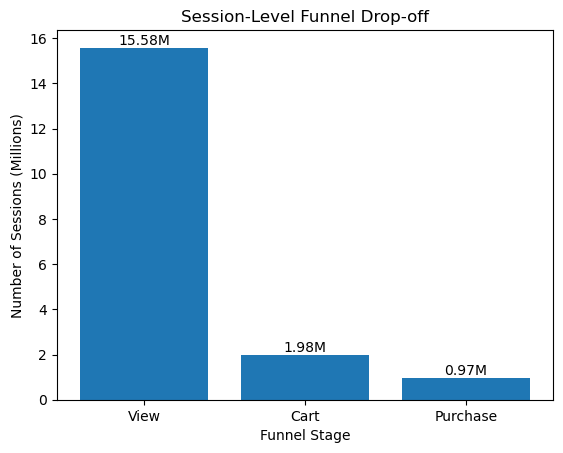

In [19]:
stages = ["View", "Cart", "Purchase"]
values = [view_sessions, cart_sessions, purchase_sessions]

# Convert to millions for readability
values_m = [v / 1_000_000 for v in values]

plt.figure()
bars = plt.bar(stages, values_m)

# Add labels
for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val / 1_000_000:.2f}M",
        ha='center',
        va='bottom'
    )

plt.title("Session-Level Funnel Drop-off")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Sessions (Millions)")

plt.show()

The bar chart highlights a steep drop-off from approximately 15.6M sessions at the view stage to around 2.0M at the cart stage, indicating that only about 12–13% of sessions progress to purchase intent. This confirms that the primary bottleneck in the funnel occurs immediately after product views.

In contrast, the transition from cart to purchase is relatively stronger, with nearly half of the cart sessions (~49%) converting into purchases. This suggests that once users demonstrate intent by adding items to the cart, they are significantly more likely to complete the transaction.

Overall, with only ~6% of sessions resulting in a purchase, improving the view-to-cart transition presents the largest opportunity to increase total conversions.

## Stage-wise Drop-off Analysis

In [20]:
view_to_cart_dropoff = 1 - view_to_cart_rate
cart_to_purchase_dropoff = 1 - cart_to_purchase_rate

view_to_cart_dropoff, cart_to_purchase_dropoff

(0.8726727805102508, 0.5109597390857616)

The drop-off analysis shows that approximately 87.3% of sessions do not progress from the view stage to the cart stage, indicating a significant loss of users at the initial stage of the funnel. This reinforces that the primary friction point lies in converting user interest into purchase intent.

Additionally, around 51.1% of sessions drop off between the cart and purchase stages. While this drop-off is lower compared to the earlier stage, it still represents a substantial loss, suggesting potential friction in the checkout process.

# User Conversion Behavior Analysis

To complement the session-level analysis, user behavior is also examined at the user level. This helps determine whether users tend to convert within a single session or across multiple sessions over time.

## User-Level Aggregation

In [21]:
user_funnel = df.groupby("user_id")["event_type"].value_counts().unstack(fill_value=0)

## User-Level Aggregated Data Preview

In [22]:
user_funnel.head()

event_type,cart,purchase,view
user_id,,,
29515875,0,0,1
29990697,0,0,1
30493659,0,0,2
31198833,0,0,3
32836036,0,0,1


## User-Level Funnel Construction

In [23]:
user_funnel_binary = user_funnel.copy()

user_funnel_binary["view"] = (user_funnel_binary["view"] > 0).astype(int)
user_funnel_binary["cart"] = (user_funnel_binary["cart"] > 0).astype(int)
user_funnel_binary["purchase"] = (user_funnel_binary["purchase"] > 0).astype(int)

In [24]:
total_users = user_funnel_binary.shape[0]

view_users = user_funnel_binary["view"].sum()
cart_users = user_funnel_binary["cart"].sum()
purchase_users = user_funnel_binary["purchase"].sum()

view_to_cart_user_rate = cart_users / view_users
cart_to_purchase_user_rate = purchase_users / cart_users
view_to_purchase_user_rate = purchase_users / view_users

## User-Level Funnel Metrics Output

In [25]:
print("Total users:", total_users)
print("View users:", view_users)
print("Cart users:", cart_users)
print("Purchase users:", purchase_users)

print("View → Cart rate:", view_to_cart_user_rate)
print("Cart → Purchase rate:", cart_to_purchase_user_rate)
print("View → Purchase rate:", view_to_purchase_user_rate)

Total users: 4577231
View users: 4576955
Cart users: 923868
Purchase users: 500997
View → Cart rate: 0.20185210472901743
Cart → Purchase rate: 0.5422820143137331
View → Purchase rate: 0.10946076594591819


**Key Insights:**
- At the user level, approximately 20.2% of users progress from viewing to adding items to the cart, which is higher than the session-level conversion rate (12.7%). This indicates that users often require multiple sessions before reaching purchase intent.
- The cart-to-purchase conversion rate is stronger at the user level (54.2%), suggesting that once users show intent, they are likely to complete the purchase, even if not within the same session.
- The overall view-to-purchase conversion rate (10.9%) is notably higher than the session-level rate (6.2%), highlighting that analyzing behavior across sessions provides a more complete picture of user conversion.

## Session vs User Funnel Comparison

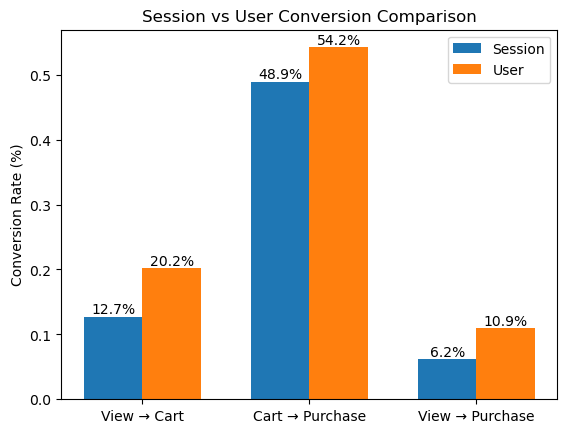

In [26]:
labels = ["View → Cart", "Cart → Purchase", "View → Purchase"]

session_rates = [
    view_to_cart_rate,
    cart_to_purchase_rate,
    view_to_purchase_rate
]

user_rates = [
    view_to_cart_user_rate,
    cart_to_purchase_user_rate,
    view_to_purchase_user_rate
]

x = np.arange(len(labels))
width = 0.35

plt.figure()

bars1 = plt.bar(x - width/2, session_rates, width, label='Session')
bars2 = plt.bar(x + width/2, user_rates, width, label='User')

# Add value labels (as percentages)
for i in range(len(labels)):
    plt.text(x[i] - width/2, session_rates[i], f"{session_rates[i]*100:.1f}%",
             ha='center', va='bottom')
    plt.text(x[i] + width/2, user_rates[i], f"{user_rates[i]*100:.1f}%",
             ha='center', va='bottom')

plt.xticks(x, labels)
plt.ylabel("Conversion Rate (%)")
plt.title("Session vs User Conversion Comparison")
plt.legend()

plt.show()

At the session level, 12.7% of sessions progress from view to cart, while at the user level this increases to 20.2%. This indicates that many users do not add items to the cart during their first visit but return later to complete this step.

The cart-to-purchase conversion rate is 48.9% at the session level and 54.2% at the user level, showing that once users add items to the cart, nearly half proceed to complete the purchase.

Overall, the view-to-purchase conversion increases from 6.2% at the session level to 10.9% at the user level, indicating that purchases often happen across multiple visits instead of a single session.

## User-Level Drop-off Analysis

In [27]:
# User-level drop-off calculation

view_to_cart_user_dropoff = 1 - view_to_cart_user_rate
cart_to_purchase_user_dropoff = 1 - cart_to_purchase_user_rate

print("View → Cart drop-off (User Level):", view_to_cart_user_dropoff)
print("Cart → Purchase drop-off (User Level):", cart_to_purchase_user_dropoff)

View → Cart drop-off (User Level): 0.7981478952709826
Cart → Purchase drop-off (User Level): 0.45771798568626687


At the user level, 79.8% of users do not progress from viewing to adding items to the cart, compared to a higher drop-off of 87.3% at the session level. This indicates that while many sessions fail to convert immediately, a portion of users return in later sessions and eventually add items to the cart. Similarly, the cart-to-purchase drop-off is 45.8% at the user level versus 51.1% at the session level, showing that users are more likely to complete purchases when their behavior is tracked across multiple sessions. Overall, the consistently lower drop-off rates at the user level suggest that conversions often occur over multiple visits rather than within a single session.

# Time-to-Conversion Analysis (User-Level)

This section analyzes how long users take to complete a purchase after their initial interaction. Since earlier analysis showed that conversions often occur across multiple sessions, understanding the time gap between first view and first purchase helps reveal user decision-making behavior and conversion delays.

## Extract First View and First Purchase per User

In [28]:
df_view = df[df['event_type'] == 'view']
df_purchase = df[df['event_type'] == 'purchase']

first_view = df_view.groupby('user_id')['event_time'].min().rename('first_view_time')
first_purchase = df_purchase.groupby('user_id')['event_time'].min().rename('first_purchase_time')

## Compute Time to Conversion (in Hours)

In [29]:
conversion_df = first_view.to_frame().join(first_purchase, how='inner')

conversion_df['time_to_conversion_hours'] = (
    (conversion_df['first_purchase_time'] - conversion_df['first_view_time'])
    .dt.total_seconds() / 3600
)

## Validate Time-to-Conversion Data

In [30]:
print("Shape:", conversion_df.shape)
print("\nMissing Values:\n", conversion_df.isnull().sum())
print("\nSummary Statistics:\n", conversion_df['time_to_conversion_hours'].describe())

Shape: (500899, 3)

Missing Values:
 first_view_time             0
first_purchase_time         0
time_to_conversion_hours    0
dtype: int64

Summary Statistics:
 count    500899.000000
mean        126.677426
std         180.704945
min        -697.830556
25%           0.086667
50%          14.609167
75%         220.524028
max         735.189722
Name: time_to_conversion_hours, dtype: float64


## Clean Invalid Time-to-Conversion Values

In [31]:
conversion_df = conversion_df[conversion_df['time_to_conversion_hours'] >= 0]

## Re-validate Time-to-Conversion Data

In [32]:
print("Shape:", conversion_df.shape)
print("\nSummary Statistics:\n", conversion_df['time_to_conversion_hours'].describe())

Shape: (500499, 3)

Summary Statistics:
 count    500499.000000
mean        126.804597
std         180.703766
min           0.002222
25%           0.086944
50%          14.757778
75%         220.745833
max         735.189722
Name: time_to_conversion_hours, dtype: float64


## Conversion Time Distribution 

In [33]:
# Create time bins (in hours)
bins = [0, 1, 24, 72, 168, 720]
labels = ['<1 hour', '1–24 hours', '1–3 days', '3–7 days', '7–30 days']

conversion_df['conversion_time_bucket'] = pd.cut(
    conversion_df['time_to_conversion_hours'],
    bins=bins,
    labels=labels
)

# Calculate distribution
bucket_dist = (
    conversion_df['conversion_time_bucket']
    .value_counts(normalize=True)
    .sort_index()
)

# Convert to percentage
bucket_dist_percent = bucket_dist * 100

bucket_dist_percent

conversion_time_bucket
<1 hour       43.743740
1–24 hours     9.066354
1–3 days       7.608676
3–7 days       9.956636
7–30 days     29.624594
Name: proportion, dtype: float64

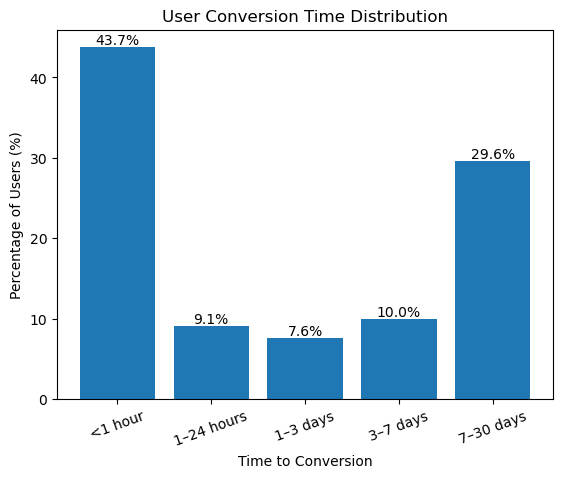

In [34]:
# Plot
plt.figure()
bars = plt.bar(bucket_dist_percent.index.astype(str), bucket_dist_percent.values)

# Add percentage labels
for bar, val in zip(bars, bucket_dist_percent.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{val:.1f}%",
        ha='center',
        va='bottom'
    )

plt.xlabel("Time to Conversion")
plt.ylabel("Percentage of Users (%)")
plt.title("User Conversion Time Distribution")

plt.xticks(rotation=20)

plt.show()

A significant 43.7% of users convert within the first hour, indicating strong immediate purchase intent. However, a large 29.6% of users take 7–30 days to convert, showing that many users require extended consideration before purchasing.

Additionally, around 17.6% convert within 1–7 days, reinforcing that nearly half of the conversions happen beyond the first day.

This highlights two distinct behaviors: quick conversions driven by high intent and delayed conversions requiring multiple touchpoints, emphasizing the importance of both immediate optimization and long-term engagement strategies.

# Category Conversion Performance

This section analyzes how user behavior varies across different product categories. By examining funnel progression (view → cart → purchase) at the category level, we aim to identify which categories perform well and where major drop-offs occur.

Understanding these differences helps uncover category-specific friction points and opportunities to improve conversion performance.

## Category-Level Aggregation

In [35]:
category_funnel = (
    df.groupby("category_code_clean")["event_type"]
      .value_counts()
      .unstack(fill_value=0)
)

## Category-Level Aggregated Data Preview

In [36]:
category_funnel.head()

event_type,cart,purchase,view
category_code_clean,,,
accessories.bag,13159,3938,516351
accessories.umbrella,910,238,54025
accessories.wallet,9873,3169,300989
apparel.belt,228,78,7752
apparel.costume,17256,5191,447887


## Category-Level Conversion Metrics

In [37]:
category_metrics = category_funnel.copy()

category_metrics["view_to_cart_rate"] = category_metrics["cart"] / category_metrics["view"]
category_metrics["cart_to_purchase_rate"] = category_metrics["purchase"] / category_metrics["cart"]
category_metrics["view_to_purchase_rate"] = category_metrics["purchase"] / category_metrics["view"]

category_metrics.head()

event_type,cart,purchase,view,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
category_code_clean,,,,,,
accessories.bag,13159,3938,516351,0.025485,0.299263,0.007627
accessories.umbrella,910,238,54025,0.016844,0.261538,0.004405
accessories.wallet,9873,3169,300989,0.032802,0.320976,0.010529
apparel.belt,228,78,7752,0.029412,0.342105,0.010062
apparel.costume,17256,5191,447887,0.038528,0.300823,0.011590


## Top Performing Categories (by Conversion Rate)

In [38]:
top_categories = (
    category_metrics
    .sort_values(by="view_to_purchase_rate", ascending=False)
    .head(10)
)

top_categories

event_type,cart,purchase,view,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
category_code_clean,,,,,,
construction.tools.light,1274073,502064,14696010,0.086695,0.394062,0.034163
sport.bicycle,166507,58750,2135188,0.077982,0.352838,0.027515
country_yard.furniture.hammok,1556,492,21199,0.073400,0.316195,0.023209
appliances.kitchen.coffee_grinder,24542,11054,549194,0.044687,0.450412,0.020128
apparel.shoes.slipons,32482,11985,608241,0.053403,0.368974,0.019704
appliances.kitchen.washer,57840,19532,1002353,0.057704,0.337690,0.019486
appliances.personal.massager,132775,45632,2429863,0.054643,0.343679,0.018780
furniture.bathroom.bath,13039,4704,253699,0.051396,0.360764,0.018542
auto.accessories.alarm,3523,1077,60610,0.058126,0.305705,0.017769


**Top Categories – Key Observations**

- The highest performing category (construction.tools.light) has a **~3.4% view-to-purchase rate**, indicating that even top categories experience significant drop-offs.

- Categories like **sport.bicycle (~2.75%)** and **hammok (~2.32%)** show relatively strong conversion, suggesting higher purchase intent in specific-use or niche products.

- Some categories (e.g., **coffee grinder, washer**) have **strong cart-to-purchase rates (~33%–45%)**, indicating effective conversion once users reach the cart stage.

- Overall, conversion performance varies across categories, highlighting that **product type and user intent play a key role in funnel efficiency**.

## Bottom Performing Categories (by Conversion Rate)

In [39]:
bottom_categories = (
    category_metrics
    .sort_values(by="view_to_purchase_rate", ascending=True)
    .head(10)
)

bottom_categories

event_type,cart,purchase,view,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
category_code_clean,,,,,,
country_yard.furniture.bench,0,0,1,0.000000,NaN,0.000000
sport.diving,115,27,9240,0.012446,0.234783,0.002922
apparel.dress,501,159,48748,0.010277,0.317365,0.003262
computers.peripherals.camera,278,46,13642,0.020378,0.165468,0.003372
computers.components.motherboard,248,90,24263,0.010221,0.362903,0.003709
accessories.umbrella,910,238,54025,0.016844,0.261538,0.004405
furniture.living_room.shelving,300,81,15738,0.019062,0.270000,0.005147
computers.peripherals.keyboard,261,61,11785,0.022147,0.233716,0.005176
auto.accessories.parktronic,271,74,13723,0.019748,0.273063,0.005392


**Bottom Categories – Key Observations**

- Several categories show **extremely low conversion rates (<0.5%)**, with some (e.g., furniture.bench) having **no meaningful activity**, indicating low demand or data sparsity.

- Categories like **apparel.dress (~0.33%)** and **camera (~0.34%)** have very low view-to-purchase rates, suggesting strong drop-off after initial interest.

- Many low-performing categories also have **weak view-to-cart rates (~1%–2%)**, indicating that users are not progressing beyond browsing.

- In some cases (e.g., motherboard), cart-to-purchase is relatively decent, but **low cart entry itself limits overall conversion**, pointing to issues earlier in the funnel.

- Overall, these categories highlight **key drop-off zones at the top of the funnel**, suggesting problems in product appeal, pricing, or initial user engagement.

## Category-Level Conversion Distribution

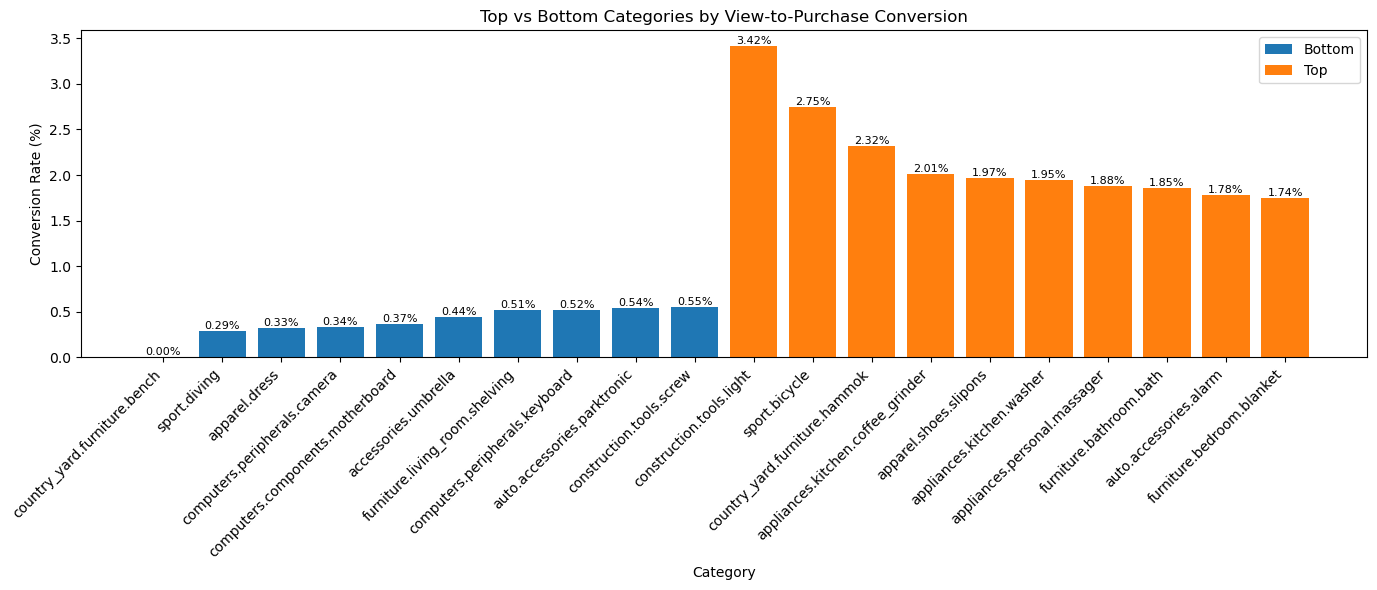

In [58]:
plt.figure(figsize=(14, 6))

combined = pd.concat([
    top_categories.assign(type="Top"),
    bottom_categories.assign(type="Bottom")
])

for group, data in combined.groupby("type"):
    bars = plt.bar(
        data.index.astype(str),
        data["view_to_purchase_rate"] * 100,
        label=group
    )
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2f}%",
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.xticks(rotation=45, ha='right')
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Category")
plt.title("Top vs Bottom Categories by View-to-Purchase Conversion")

plt.legend()
plt.tight_layout()
plt.show()

## Category Comparison – Key Insight

- Top categories achieve **~1.7% to 3.4% conversion**, while bottom categories remain below **~0.6%**, showing a clear performance gap.

- The difference is driven mainly by **low view-to-cart rates in bottom categories**, indicating weak initial user engagement.

- Some bottom categories still convert reasonably after cart, suggesting that the primary issue lies in **attracting user interest rather than checkout performance**.

# Brand Conversion Performance

This section evaluates conversion performance across different brands to identify which brands drive higher engagement and purchases. This helps uncover differences in brand trust, pricing perception, and product appeal.

## Brand-Level Aggregation

In [43]:
brand_funnel = (
    df.groupby("brand_clean")["event_type"]
      .value_counts()
      .unstack(fill_value=0)
)

## Brand-Level Aggregated Data Preview

In [44]:
brand_funnel.head()

event_type,cart,purchase,view
brand_clean,,,
a-case,960,197,27717
a-derma,31,6,580
a-elita,15,6,658
a-mega,5,2,144
aardwolf,28,8,788


## Brand-Level Conversion Metrics

In [45]:
brand_metrics = brand_funnel.copy()

brand_metrics["view_to_cart_rate"] = brand_metrics["cart"] / brand_metrics["view"]
brand_metrics["cart_to_purchase_rate"] = brand_metrics["purchase"] / brand_metrics["cart"]
brand_metrics["view_to_purchase_rate"] = brand_metrics["purchase"] / brand_metrics["view"]

In [46]:
top_brands = (
    brand_metrics
    .sort_values(by="view_to_purchase_rate", ascending=False)
    .head(10)
)

top_brands

event_type,cart,purchase,view,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
brand_clean,,,,,,
vasin,5,4,11,0.454545,0.800000,0.363636
naturalist,3,2,9,0.333333,0.666667,0.222222
egmont,2,1,5,0.400000,0.500000,0.200000
individuumprint,3,2,14,0.214286,0.666667,0.142857
voltajr,10,7,54,0.185185,0.700000,0.129630
mfmaster,8,5,41,0.195122,0.625000,0.121951
puridea,4,4,33,0.121212,1.000000,0.121212
sibin,24,18,158,0.151899,0.750000,0.113924
defacto,13,9,89,0.146067,0.692308,0.101124


The above results are influenced by very low-volume brands, where small numbers of events lead to inflated conversion rates. To ensure meaningful and reliable insights, brands with insufficient activity will be filtered out before further analysis.

## Filter Brands with Sufficient Activity

In [47]:
brand_metrics_filtered = brand_metrics[brand_metrics["view"] >= 1000]

## Top Performing Brands 

In [48]:
top_brands_filtered = (
    brand_metrics_filtered
    .sort_values(by="view_to_purchase_rate", ascending=False)
    .head(10)
)

top_brands_filtered

event_type,cart,purchase,view,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
brand_clean,,,,,,
ea,1739,591,11600,0.149914,0.339850,0.050948
tyrex,273,115,2321,0.117622,0.421245,0.049548
badlandgames,472,159,3597,0.131220,0.336864,0.044204
apple,490863,209511,4880232,0.100582,0.426822,0.042931
casada,321,153,3583,0.089590,0.476636,0.042702
annaite,139,43,1023,0.135875,0.309353,0.042033
samga,290,90,2212,0.131103,0.310345,0.040687
moony,107,39,1019,0.105005,0.364486,0.038273
bestoy,1369,560,15770,0.086810,0.409058,0.035510


## Low-Converting Brands 

In [49]:
bottom_brands_filtered = (
    brand_metrics_filtered
    .sort_values(by="view_to_purchase_rate", ascending=True)
    .head(10)
)

bottom_brands_filtered

event_type,cart,purchase,view,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
brand_clean,,,,,,
domenik,6,0,1336,0.004491,0.0,0.0
vitebskiekovry,8,0,1436,0.005571,0.0,0.0
carahardwood,7,0,1472,0.004755,0.0,0.0
comma,11,0,1018,0.010806,0.0,0.0
vitus,1,0,1102,0.000907,0.0,0.0
vivitek,8,0,1078,0.007421,0.0,0.0
louiserard,6,0,2433,0.002466,0.0,0.0
trevi,6,0,2692,0.002229,0.0,0.0
calgaro,2,0,1103,0.001813,0.0,0.0


## Top vs Low-Converting Brands by View-to-Purchase Conversion

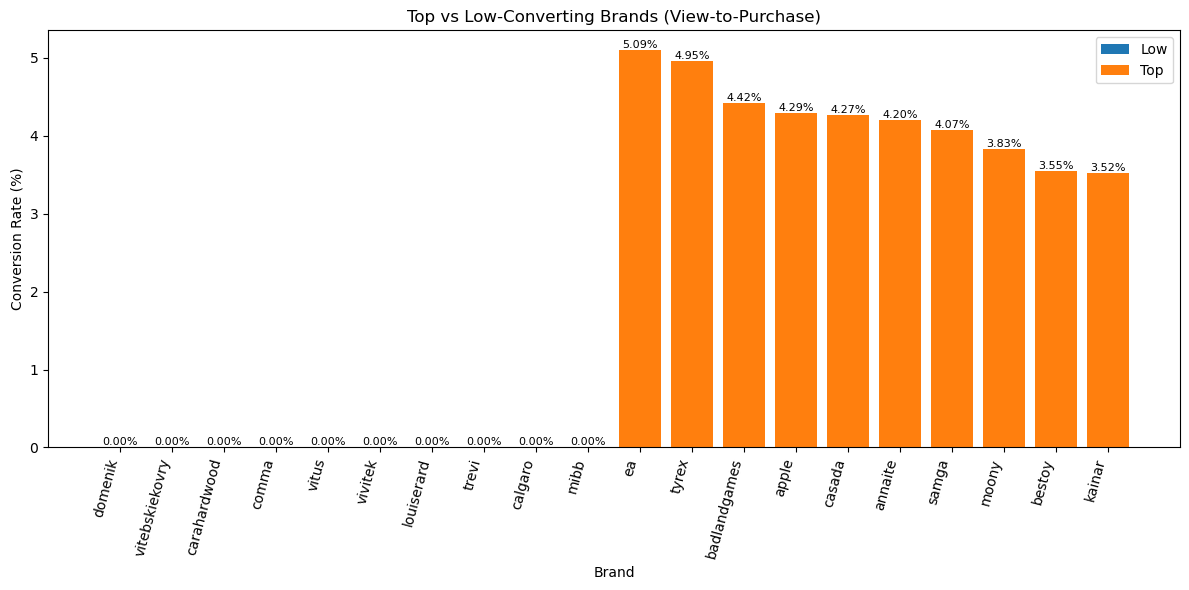

In [57]:
# Combine top and low-performing brands
combined_brands = pd.concat([
    top_brands_filtered.assign(type="Top"),
    bottom_brands_filtered.assign(type="Low")
])

plt.figure(figsize=(12, 6))

for group, data in combined_brands.groupby("type"):
    bars = plt.bar(
        data.index.astype(str),
        data["view_to_purchase_rate"] * 100,
        label=group
    )
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2f}%",
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.xticks(rotation=75, ha='right')
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Brand")
plt.title("Top vs Low-Converting Brands (View-to-Purchase)")
plt.legend()

plt.tight_layout()
plt.show()

The comparison highlights a clear gap between high-performing and low-converting brands. Brands such as ea and tyrex achieve view-to-purchase conversion rates above 4.5%, indicating strong effectiveness in converting user interest into purchases. 
In contrast, brands like domenik, vitebskiekovry, and carahardwood show near-zero conversion despite having over 1,000 product views, indicating a complete drop-off before purchase

This disparity suggests that while some brands successfully drive user trust and purchase intent, others fail to convert engagement into sales, potentially due to issues such as weak product appeal, pricing misalignment, or lack of brand credibility.

## Price Sensitivity & Conversion Analysis

This section examines how product pricing influences user conversion behavior across the funnel. By analyzing conversion rates across different price ranges, we aim to identify whether pricing acts as a barrier or driver of purchase decisions. This helps uncover opportunities for pricing optimization to improve overall conversion performance.

### Creating Price Buckets for Analysis

In [51]:
# Create price buckets
bins = [0, 50, 100, 200, 500, 1000, float('inf')]
labels = ['0-50', '50-100', '100-200', '200-500', '500-1000', '1000+']

df['price_bucket'] = pd.cut(df['price'], bins=bins, labels=labels)

df[['price', 'price_bucket']].head()

,price,price_bucket
0,1302.48,1000+
1,102.96,100-200
2,313.52,200-500
3,132.31,100-200
4,101.68,100-200


### Conversion Metrics by Price Range

In [54]:
price_funnel = (
    df.groupby("price_bucket", observed=False)["event_type"]
    .value_counts()
    .unstack(fill_value=0)
)

price_metrics = price_funnel.copy()

price_metrics["view_to_cart_rate"] = price_metrics["cart"] / price_metrics["view"]
price_metrics["cart_to_purchase_rate"] = price_metrics["purchase"] / price_metrics["cart"]
price_metrics["view_to_purchase_rate"] = price_metrics["purchase"] / price_metrics["view"]

price_metrics

event_type,cart,purchase,view,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
price_bucket,,,,,,
0-50,654611,179891,13135204,0.049836,0.274806,0.013695
50-100,432963,147297,9886817,0.043792,0.340207,0.014898
100-200,867503,326203,14174175,0.061203,0.376025,0.023014
200-500,821835,305042,15903323,0.051677,0.371172,0.019181
500-1000,382823,154050,7074815,0.054111,0.402405,0.021774
1000+,123486,49545,2748100,0.044935,0.401220,0.018029


### Conversion Rate by Price Range

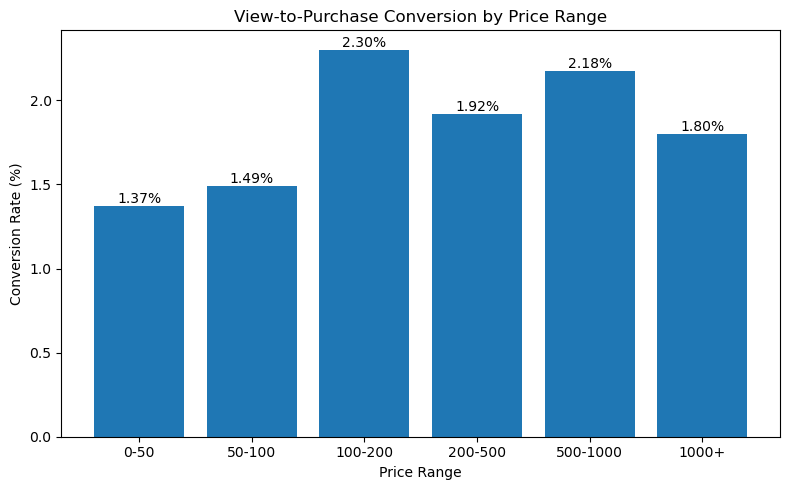

In [56]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    price_metrics.index.astype(str),
    price_metrics["view_to_purchase_rate"] * 100
)

plt.xlabel("Price Range")
plt.ylabel("Conversion Rate (%)")
plt.title("View-to-Purchase Conversion by Price Range")

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}%",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

The relationship between price and conversion is non-linear. Mid-range products (100–200) achieve the highest conversion rate (~2.30%), indicating an optimal balance between affordability and perceived value.

Lower-priced products (0–100) show comparatively lower conversion rates (1.37%–1.49%) despite high visibility, suggesting weaker purchase intent or lower perceived value. Conversely, very high-priced products (1000+) also exhibit reduced conversion (1.80%), likely due to increased purchase hesitation.

Overall, products in the mid-price range outperform both low- and high-priced items, highlighting pricing as a key factor influencing conversion behavior.

## Insights Summary

Based on the comprehensive funnel analysis across session-level, user-level, time-to-conversion, category, brand, and pricing dimensions, several key insights emerge:

- **The primary bottleneck in the funnel occurs at the view → cart stage**, where a large majority of users drop off. Despite high product visibility, only a small proportion of users demonstrate purchase intent by adding items to the cart.

- **Users often require multiple sessions to convert**, as evidenced by higher conversion rates at the user level compared to the session level. This indicates that purchases are not always immediate and may involve repeated visits and consideration.

- **Once users add items to the cart, conversion likelihood significantly increases**, with relatively strong cart → purchase rates across both session and user levels. This suggests that intent-driven users face fewer barriers in completing transactions.

- **User behavior exhibits two distinct conversion patterns**:
  - Immediate conversions within a short time (high-intent users)
  - Delayed conversions over several days or weeks (consideration-driven users)

- **Category-level performance varies significantly**, with some categories achieving relatively higher conversion rates due to stronger purchase intent, while others experience major drop-offs at early stages of the funnel.

- **Low-performing categories are primarily affected by weak view → cart transitions**, indicating issues related to product appeal, pricing, or user engagement rather than checkout friction.

- **Brand-level analysis reveals a strong disparity in conversion performance**, where high-performing brands such as *ea* and *tyrex* convert effectively, while others like *domenik* and *vitus* fail to generate purchases despite substantial visibility.

- **Low-converting brands show near-zero conversion despite sufficient traffic**, suggesting potential issues such as lack of trust, poor product positioning, or misaligned pricing strategies.

- **Pricing plays a critical role in conversion behavior**, with mid-range products (100–200) achieving the highest conversion rates (~2.30%), while both low-priced (0–100) and high-priced (1000+) products show reduced conversion. This indicates that users are more likely to purchase products that balance affordability with perceived value.

- **Conversion performance is influenced by a combination of category, brand perception, and pricing**, highlighting the importance of aligning product positioning, trust signals, and value perception to drive purchases.tion to drive purchases.

Overall, the analysis indicates that improving early-stage engagement (view → cart), strengthening trust at the brand level, and optimizing pricing strategies present the gincreasing overall conversion rates.

## Business Recommendations

Based on the insights derived from the funnel analysis, the following data-driven recommendations are proposed to improve conversion performance and overall sales:

- **Improve View → Cart Conversion (Primary Bottleneck)**  
  With ~87% session-level drop-off at this stage, product pages should be optimized with clearer pricing, high-quality images, detailed descriptions, and prominent call-to-action (CTA) buttons to encourage add-to-cart actions.

- **Strengthen Product Trust Signals for Low-Converting Brands**  
  Brands such as *domenik*, *vitus*, and *carahardwood* show near-zero conversion despite significant traffic. Introducing customer reviews, ratings, trust badges, and clearer product guarantees can improve credibility and purchase confidence.

- **Leverage Retargeting for Delayed Conversions**  
  Since ~29.6% of users convert within 7–30 days, implementing retargeting strategies (e.g., email reminders, personalized ads, abandoned cart notifications) can help capture users who require longer decision cycles.

- **Optimize Pricing Strategy for Better Conversion**  
  Mid-priced products (100–200) show the highest conversion (~2.30%), indicating an optimal value perception. Businesses should evaluate pricing strategies for both low-priced and high-priced products, potentially adjusting price positioning, bundling, or discounting to improve perceived value.

- **Reposition Low-Priced Products to Increase Perceived Value**  
  Products in the 0–100 range show relatively low conversion despite high visibility. Enhancing product presentation, bundling items, or emphasizing quality and benefits can help increase purchase intent.

- **Reduce Purchase Hesitation for High-Priced Products**  
  High-priced items (1000+) experience lower conversion likely due to higher risk perception. Offering financing options, discounts, warranties, and stronger trust signals can help reduce hesitation and improve conversions.

- **Optimize High-Performing Categories for Revenue Growth**  
  Categories like *construction.tools.light* and *sport.bicycle* demonstrate relatively higher conversion rates. These should be prioritized in promotions, recommendations, and inventory planning to maximize revenue impact.

- **Improve Engagement in Low-Performing Categories**  
  Categories with very low view-to-cart rates (e.g., *apparel.dress*, *camera*) should be evaluated for pricing, product positioning, and visual appeal to increase initial user engagement.

- **Simplify Checkout Process to Reduce Cart Drop-off**  
  With ~51% session-level drop-off from cart to purchase, reducing friction through guest checkout, fewer form fields, and multiple payment options can improve completion rates.

- **Personalize User Experience Across Sessions**  
  Since users often convert across multiple sessions, personalized recommendations, recently viewed items, and session continuity features can help guide users back into the funnel.

- **Prioritize High-Intent Users for Conversion Optimization**  
  Users who add items to cart already show strong purchase intent (~49–54% conversion). Targeting these users with urgency signals (e.g., limited stock, limited-time offers) can further improve purchase completion.

Overall, focusing on early-stage engagement, pricing optimization, trust-building, and targeted retention strategies can significantly enhance funnel efficiency and drive higher conversions.

## Conclusion

This analysis explored user behavior across the e-commerce conversion funnel using over 67 million interaction events. By examining funnel progression at both session and user levels, along with time-to-conversion, category, brand, and pricing dimensions, several critical patterns were identified.

The findings reveal that the most significant drop-off occurs at the early stage of the funnel (view → cart), indicating a gap between user interest and purchase intent. While conversion improves significantly once users reach the cart stage, overall funnel efficiency remains limited due to weak initial engagement.

The analysis also shows that users often require multiple sessions before converting, and a substantial portion of purchases occur after delayed decision-making periods. Additionally, conversion performance varies widely across categories, brands, and price ranges, highlighting the combined influence of product type, trust, and perceived value.

In particular, mid-priced products demonstrate higher conversion compared to both low- and high-priced items, emphasizing the importance of pricing strategy in shaping purchase behavior.

These insights suggest that improving early-stage engagement, strengthening brand trust, and optimizing pricing and product positioning are key to enhancing conversion rates.

By implementing targeted strategies based on these findings, businesses can optimize their conversion funnel, improve user experience, and drive sustainable growth in revenue.